# Land cover change in the Rondônia deforestation arc, Brazil

For this assignment I picked deforestation as the use case. Rondônia is one of the most closely watched deforestation fronts in the Brazilian Amazon, so there is enough independent data to sanity check whatever the pipeline finds.

Some numbers to set the scene. Rondônia held about 14 million hectares of natural forest in 2020, covering 57 percent of the state, and has been losing roughly 230 thousand hectares a year (Global Forest Watch, based on Hansen/UMD data). At the scale of the whole Brazilian Amazon, INPE's PRODES program recorded annual deforestation rising from 7,536 km2 in 2018 to a peak of 13,235 km2 in 2021, then falling by about 11 percent in 2022 and 22 percent in 2023. My comparison window, 2018 to 2023, sits right across that peak and the turnaround that followed. The dominant driver in this region is cattle ranching, land is cleared and converted to pasture, with estimates putting around 70 to 80 percent of cleared Amazon land under pasture afterwards.

I'm using Sentinel-2 L2A as the data source. I looked at the other options mentioned in the brief before settling on it. Landsat has a native resolution of 30 meters, which felt too coarse for the parcel sized changes I wanted to catch inside a small AOI. Sentinel-1 is radar, so it does not give me optical bands, which means no NDVI or NBR directly from it, it would only make sense as a complement, not as the main source. HLS fuses Landsat and Sentinel-2 to get more frequent observations, but that fusion adds a layer of harmonization work I did not need here, since Sentinel-2 alone already revisits every 5 days, which turned out to be enough to find clean scenes within the dry season windows I chose.

The comparison is between two dry season windows, June to September 2018 and June to September 2023. I kept both windows in the same months on purpose, so seasonal effects on vegetation don't get mixed up with the actual change I'm trying to measure. The AOI itself ends up small, about 10 by 10 km, a deliberate trade-off explained in the AOI selection section below and revisited in the limits at the end.

Sources for the numbers above: Global Forest Watch, Rondônia dashboard (globalforestwatch.org); INPE PRODES annual deforestation reports.


## Colab setup, mounting Drive so outputs persist

This project is run on Google Colab. By default anything saved with a bare filename (e.g. `"ndvi_change.tif"`) is written to the Colab VM's local, ephemeral disk (`/content/`), which is wiped when the runtime disconnects, so it never reaches Drive or a local machine. The cell below mounts Google Drive and defines `OUTPUT_DIR`, a folder inside Drive where the GeoTIFF and the two GeoJSON files produced later in the notebook are saved instead, so they survive after the session ends and can be downloaded straight from Drive.

Nothing else in the pipeline changes, this only affects where the three output files land.

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

OUTPUT_DIR = "/content/drive/MyDrive/Deforestation_Detection/outputs"  # edit this path if you keep the project elsewhere in Drive
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Saving outputs to:", OUTPUT_DIR)

Mounted at /content/drive
Saving outputs to: /content/drive/MyDrive/Deforestation_Detection/outputs


In [2]:
!pip install -q pystac-client planetary-computer odc-stac rioxarray rasterio geopandas shapely contextily folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.6/159.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt
import contextily as cx
from shapely.geometry import box, mapping, shape, Point

import pystac_client
import planetary_computer as pc
import odc.stac
from rasterio.features import shapes as raster_to_shapes
import folium
from folium.plugins import GroupedLayerControl
import matplotlib.cm as cm
import matplotlib.colors as mcolors


## Setting the time windows

Both windows sit in the dry season, when cloud cover in this part of the Amazon is at its lowest. That gives the best chance of finding enough clean acquisitions in each period.


In [4]:
baseline_window = "2018-06-01/2018-09-30"
recent_window = "2023-06-01/2023-09-30"
# format STAC APIs expect when you filter a search by a date range

## Connecting to the Planetary Computer catalog

I'm using Microsoft's Planetary Computer as the data backend. It exposes a standard STAC API, so I can search Sentinel-2 scenes by area, date and cloud cover without downloading anything yet. The sign_inplace part matters because the actual image files sit on Azure storage behind temporary signed links, without it every download later would fail with a permission error.

One practical consequence, those signed links expire, typically within a day. If a kernel session sits idle for a long time between searching for scenes and actually reading their pixels, reads can start failing with a confusing low level rasterio error, which can even surface as a stray NotGeoreferencedWarning as a side effect of the failed read rather than anything about the georeferencing itself. The fix is just re-running from the search step to get fresh signed links, not a change to the processing logic.


In [5]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

## Finding a safe AOI

I ran into an issue early on and I'm walking through it here rather than skipping straight to the fix. Sentinel-2 delivers imagery in 110 by 110 km tiles projected onto a fixed UTM grid, but the actual imaged area for a given date comes from a satellite pass (a datatake) that doesn't necessarily fill the whole tile edge to edge, ESA's own documentation flags the swath border area specifically as a place where data can be missing or degraded. My first AOI happened to land in a spot barely touched by the pass for that tile, which is why every image I downloaded came back basically blank, even though the tile itself, on paper, covered the area.

To avoid picking another bad spot by luck, I search for a scene near a known deforestation area, take its real footprint geometry instead of the tile's nominal square boundary, shrink that footprint inward a bit to stay clear of the edges, and grab a point that is guaranteed to sit well inside the actually-imaged area. The AOI is then built around that point.The AOI itself ends up small, about 10 by 10 km, a deliberate trade-off explained in the AOI selection section below and revisited in the limits at the end.

In [6]:
reference_point = Point(-63.90, -8.76)
wide_search_area = reference_point.buffer(0.5)

candidates_nearby = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=mapping(wide_search_area),
    datetime=recent_window,
    query={"eo:cloud_cover": {"lt": 30}},
).items()
candidates_nearby = list(candidates_nearby)
print(len(candidates_nearby), "scenes found nearby")

# pick the scene whose real footprint covers the most area, usually the one furthest from a tile edge
reference_scene = max(candidates_nearby, key=lambda item: shape(item.geometry).area)
footprint = shape(reference_scene.geometry)
inner_point = footprint.buffer(-0.15).representative_point()

half_size = 0.05  # roughly a 10 km box
bbox = [inner_point.x - half_size, inner_point.y - half_size,
        inner_point.x + half_size, inner_point.y + half_size]
aoi = box(*bbox)
aoi_geojson = mapping(aoi)

print("bbox:", bbox)

243 scenes found nearby
bbox: [-63.461313123204675, -9.592136744908483, -63.36131312320468, -9.492136744908482]


In [7]:
def real_coverage(item, aoi_polygon):
    """how much of the AOI actually falls inside this item's real footprint,
    as opposed to the tile's bounding box"""
    footprint = shape(item.geometry)
    return footprint.intersection(aoi_polygon).area / aoi_polygon.area

coverage = real_coverage(reference_scene, aoi)
print(f"coverage of the AOI by this scene: {coverage * 100:.1f}%")

coverage of the AOI by this scene: 100.0%


## Where this AOI sits

Before going further it helps to actually see where this small box lands, both on its own and in the wider regional picture, rather than just trusting a list of four coordinates. The regional view below is centered on the search point used to find a safe AOI, not on the AOI itself, so the small box may sit slightly off-center in that wider view.


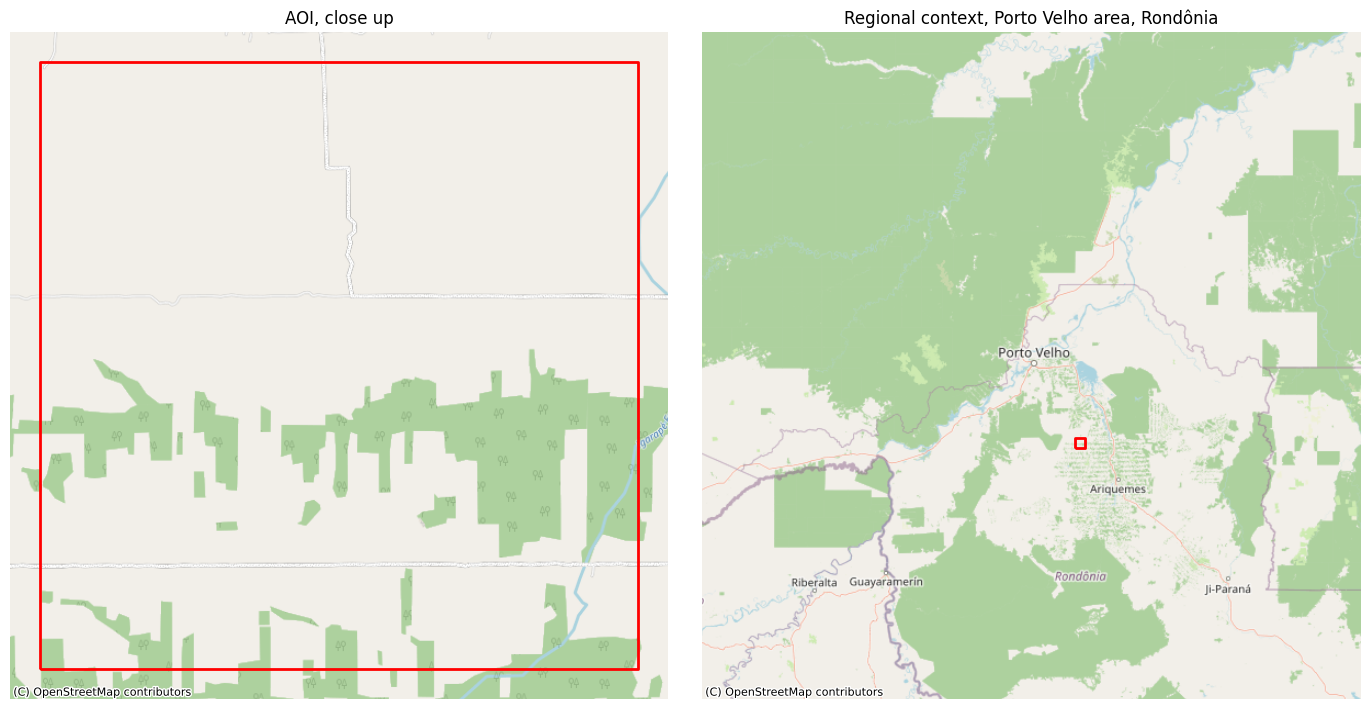

In [8]:
aoi_gdf = gpd.GeoDataFrame(geometry=[aoi], crs="EPSG:4326").to_crs(epsg=3857)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

aoi_gdf.boundary.plot(ax=axes[0], color="red", linewidth=2)
cx.add_basemap(axes[0], source=cx.providers.OpenStreetMap.Mapnik)
axes[0].set_title("AOI, close up")
axes[0].set_axis_off()

wide_area = reference_point.buffer(3.0)  # roughly 300 km across
wide_gdf = gpd.GeoDataFrame(geometry=[box(*wide_area.bounds)], crs="EPSG:4326").to_crs(epsg=3857)
wide_gdf.plot(ax=axes[1], alpha=0)
aoi_gdf.boundary.plot(ax=axes[1], color="red", linewidth=2)
cx.add_basemap(axes[1], source=cx.providers.OpenStreetMap.Mapnik)
axes[1].set_title("Regional context, Porto Velho area, Rondônia")
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig("aoi_location_maps.png", dpi=150)
plt.show()


## Searching acquisitions for each period

Cloud cover on a STAC item is computed over the whole tile, not just the AOI, so a scene can look mostly clear on paper and still have the AOI sitting under one isolated cloud. Because of that I search with a fairly loose cloud threshold and a wide pool of candidates, and only decide which scenes are actually good once cloud cover inside the AOI itself is checked, in the next step.


In [9]:
def find_candidates(time_window, cloud_ceiling=40, pool_size=30):
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        intersects=aoi_geojson,
        datetime=time_window,
        query={"eo:cloud_cover": {"lt": cloud_ceiling}},
    )
    found = list(search.items())
    found.sort(key=lambda item: item.properties["eo:cloud_cover"])
    return found[:pool_size]

baseline_candidates = find_candidates(baseline_window)
recent_candidates = find_candidates(recent_window)
print("baseline candidates:", len(baseline_candidates))
print("recent candidates:", len(recent_candidates))

baseline candidates: 18
recent candidates: 30


## Picking the actual scenes to use

For each candidate I load only the SCL band, which is cheap, and check how much of the AOI is actually clear. I also ran into duplicate acquisitions here, Planetary Computer sometimes lists the same satellite overpass twice under two different processing versions, same timestamp, different item id. If those aren't filtered out, one real acquisition would be counted as two, which quietly breaks the at least 6 real acquisitions requirement. I kept 5 scenes per period instead of 3, mainly so the median and the time series later are less sensitive to any single noisy date.


In [10]:
cloud_related_classes = [0, 1, 3, 8, 9, 10, 11]  # no data, saturated, shadow, clouds, cirrus, snow

def aoi_clear_fraction(item):
    scl = odc.stac.load([item], bands=["SCL"], bbox=bbox, resolution=20, chunks={})
    scl = scl.isel(time=0)["SCL"]
    return float((~scl.isin(cloud_related_classes)).mean().values)

def pick_scenes(candidates, how_many=5, min_clear=0.6):
    scored = [(aoi_clear_fraction(item), item) for item in candidates]

    by_datetime = {}
    for clear_fraction, item in scored:
        dt = item.properties["datetime"]
        if dt not in by_datetime or item.id > by_datetime[dt][1].id:
            by_datetime[dt] = (clear_fraction, item)
    unique_scenes = list(by_datetime.values())

    unique_scenes.sort(key=lambda x: x[0], reverse=True)
    good_ones = [item for clear_fraction, item in unique_scenes if clear_fraction >= min_clear]

    if len(good_ones) < how_many:
        print(f"only {len(good_ones)} scenes above {min_clear*100:.0f}% clear, using the best available instead")
        return [item for _, item in unique_scenes[:how_many]]
    return good_ones[:how_many]

print("baseline scenes:")
baseline_scenes = pick_scenes(baseline_candidates)
for item in baseline_scenes:
    print(" ", item.id, item.properties["datetime"][:10])

print("recent scenes:")
recent_scenes = pick_scenes(recent_candidates)
for item in recent_scenes:
    print(" ", item.id, item.properties["datetime"][:10])

total_scenes = len(baseline_scenes) + len(recent_scenes)
assert total_scenes >= 6, "not enough clean scenes, try widening the date range"
print(f"{total_scenes} acquisitions in total")


baseline scenes:
  S2A_MSIL2A_20180819T142751_R053_T20LMQ_20201011T035719 2018-08-19
  S2A_MSIL2A_20180829T142751_R053_T20LMQ_20201103T112224 2018-08-29
  S2A_MSIL2A_20180720T142751_R053_T20LMQ_20201011T175511 2018-07-20
  S2A_MSIL2A_20180908T142751_R053_T20LMQ_20201011T100319 2018-09-08
  S2A_MSIL2A_20180710T142751_R053_T20LMQ_20201011T140724 2018-07-10
recent scenes:
  S2B_MSIL2A_20230629T142719_R053_T20LMQ_20241002T184523 2023-06-29
  S2A_MSIL2A_20230724T142721_R053_T20LMQ_20230724T233545 2023-07-24
  S2A_MSIL2A_20230922T142711_R053_T20LMQ_20241026T093629 2023-09-22
  S2B_MSIL2A_20230828T142719_R053_T20LMQ_20241019T002816 2023-08-28
  S2B_MSIL2A_20230808T142719_R053_T20LMQ_20241030T021940 2023-08-08
10 acquisitions in total


## Downloading the actual pixels

This is where the real imagery gets pulled down, band by band, for each of the selected scenes, cropped to the AOI at 10 meter resolution. Everything before this point was only metadata.


In [11]:
bands_needed = ["B02", "B03", "B04", "B08", "B8A", "B11", "B12", "SCL"]
# B08 is the broad, 10m NIR band used for NDVI/EVI/BSI everywhere else in this notebook.
# B8A is the narrow, 20m NIR band. It's downloaded here too because it's the one the
# GFM bonus section actually needs, see the note in that section for why.

def download_scene(item):
    ds = odc.stac.load([item], bands=bands_needed, bbox=bbox, resolution=10, chunks={})
    return ds.isel(time=0)

all_scenes = [("baseline", item) for item in baseline_scenes] + [("recent", item) for item in recent_scenes]

scenes = {}
for period, item in all_scenes:
    scenes[item.id] = {
        "period": period,
        "date": item.properties["datetime"],
        "data": download_scene(item),
    }
    print(f"downloaded {item.id} ({period}, {item.properties['datetime'][:10]})")

item_by_id = {item.id: item for item in baseline_scenes + recent_scenes}


downloaded S2A_MSIL2A_20180819T142751_R053_T20LMQ_20201011T035719 (baseline, 2018-08-19)
downloaded S2A_MSIL2A_20180829T142751_R053_T20LMQ_20201103T112224 (baseline, 2018-08-29)
downloaded S2A_MSIL2A_20180720T142751_R053_T20LMQ_20201011T175511 (baseline, 2018-07-20)
downloaded S2A_MSIL2A_20180908T142751_R053_T20LMQ_20201011T100319 (baseline, 2018-09-08)
downloaded S2A_MSIL2A_20180710T142751_R053_T20LMQ_20201011T140724 (baseline, 2018-07-10)
downloaded S2B_MSIL2A_20230629T142719_R053_T20LMQ_20241002T184523 (recent, 2023-06-29)
downloaded S2A_MSIL2A_20230724T142721_R053_T20LMQ_20230724T233545 (recent, 2023-07-24)
downloaded S2A_MSIL2A_20230922T142711_R053_T20LMQ_20241026T093629 (recent, 2023-09-22)
downloaded S2B_MSIL2A_20230828T142719_R053_T20LMQ_20241019T002816 (recent, 2023-08-28)
downloaded S2B_MSIL2A_20230808T142719_R053_T20LMQ_20241030T021940 (recent, 2023-08-08)


## Cloud masking and scaling, and a bug that only showed up once I checked the final numbers

This section is written the way the debugging actually happened, not cleaned up after the fact, because the fix only makes sense once you've seen what it's fixing.

Cloud masking uses the SCL band that comes with every Sentinel-2 L2A scene. SCL classifies each pixel into categories like vegetation, bare soil, water, cloud, cloud shadow, cirrus, and snow. No data, saturated or defective pixels, cloud shadow, cloud with medium or high probability, cirrus, and snow or ice are masked out, classes 0, 1, 3, 8, 9, 10, 11.

For scaling, the naive approach is just dividing the digital numbers by 10000 to get reflectance in a 0 to 1 range. That's what I did first. It produced a plausible looking pipeline end to end, composite, indices, time series, raster, polygons, decision list, all of it ran without errors. The numbers were the problem, not the code. That first version flagged 38 percent of the entire AOI as confirmed vegetation loss between 2018 and 2023, with individual contiguous polygons over 1000 hectares, nearly a tenth of the whole AOI as a single patch. For comparison, the whole state of Rondônia, one of the most intense deforestation fronts in the Amazon, loses about 1.6 percent of its forest a year. Those numbers were not remotely plausible.

My first hypothesis was that this AOI, which already looked like an agricultural mosaic rather than primary forest in the 2018 composite, was showing crop rotation or harvest timing rather than real change. I tested this directly, computing NDVI standard deviation across the 5 baseline scenes alone, same year, no possible deforestation in two months, on the theory that a managed field would already be unstable within a single year while stable forest would not. The result did not support the hypothesis well, flagged pixels had a mean baseline standard deviation of 0.066 against 0.056 for non flagged pixels, a real but small difference, and the two distributions overlapped almost completely. Whatever was driving the huge flagged area wasn't concentrated on already unstable land the way crop rotation would predict, it looked closer to a near uniform shift across the whole AOI.

A uniform shift affecting the whole area regardless of local stability pointed somewhere else, at how the two periods were being scaled, not at what was happening on the ground. Checking the STAC metadata for all 10 scenes confirmed it. Every 2018 scene reported Sentinel-2 processing baseline 02.12. Every 2023 scene reported baseline 05.09 or 05.10. Since January 25, 2022, ESA's processing baseline 04.00 introduced a per band radiometric offset, BOA_ADD_OFFSET, typically -1000 DN, so that dark surfaces would not get clipped to zero. The correct formula since that date is reflectance = (DN + BOA_ADD_OFFSET) / 10000, not just DN / 10000. Microsoft's Planetary Computer, unlike Google Earth Engine's harmonized collection, does not apply this correction automatically, it's an open request on their GitHub repository. Every one of my baseline scenes predates the change and needs no correction. Every one of my recent scenes postdates it and was silently overestimating reflectance in every band by about 0.1 before this fix, which distorts NDVI in exactly the direction that would fake a vegetation decline between periods.

The fix reads the processing baseline from each item's own metadata and only applies the offset where it actually applies, rather than hardcoding an assumption about which years need it.


In [12]:
def mask_and_scale(scene_data, item):
    scl = scene_data["SCL"]
    is_clear = ~scl.isin(cloud_related_classes)

    processing_baseline = item.properties.get("s2:processing_baseline", "00.00")
    needs_offset = float(processing_baseline.split(".")[0]) >= 4  # baseline 04.00 onward

    raw = scene_data[["B02", "B03", "B04", "B08", "B8A", "B11", "B12"]].astype("float32")
    if needs_offset:
        raw = raw - 1000  # BOA_ADD_OFFSET, standard value since processing baseline 04.00

    reflectance = raw / 10000.0
    reflectance = reflectance.where(is_clear)
    return reflectance

for scene_id, info in scenes.items():
    info["clean"] = mask_and_scale(info["data"], item_by_id[scene_id])
    baseline_used = item_by_id[scene_id].properties.get("s2:processing_baseline", "unknown")
    offset_applied = float(baseline_used.split(".")[0]) >= 4
    print(f"{scene_id[:25]}... | processing baseline {baseline_used} | offset corrected: {offset_applied}")


S2A_MSIL2A_20180819T14275... | processing baseline 02.12 | offset corrected: False
S2A_MSIL2A_20180829T14275... | processing baseline 02.12 | offset corrected: False
S2A_MSIL2A_20180720T14275... | processing baseline 02.12 | offset corrected: False
S2A_MSIL2A_20180908T14275... | processing baseline 02.12 | offset corrected: False
S2A_MSIL2A_20180710T14275... | processing baseline 02.12 | offset corrected: False
S2B_MSIL2A_20230629T14271... | processing baseline 05.10 | offset corrected: True
S2A_MSIL2A_20230724T14272... | processing baseline 05.09 | offset corrected: True
S2A_MSIL2A_20230922T14271... | processing baseline 05.10 | offset corrected: True
S2B_MSIL2A_20230828T14271... | processing baseline 05.10 | offset corrected: True
S2B_MSIL2A_20230808T14271... | processing baseline 05.10 | offset corrected: True


## Checking how much usable data actually survived masking

One honest caveat about what this check does and does not prove. Scenes were already selected for being mostly clear inside the AOI, so this is largely confirming a condition already imposed during scene selection rather than an independent check. It is still useful as a final look before trusting the median, mainly to catch a scene that looked clear in aggregate but has one bad patch sitting exactly inside this smaller AOI.


In [13]:
def valid_observation_count(period_name, band="B04"):
    period_scenes = [info["clean"][band] for info in scenes.values() if info["period"] == period_name]
    stack = xr.concat(period_scenes, dim="time")
    return (~stack.isnull()).sum(dim="time")

for period_name in ["baseline", "recent"]:
    valid_count = valid_observation_count(period_name)
    mean_valid = float(valid_count.mean().values)
    pct_well_covered = float((valid_count >= 3).mean().values) * 100
    print(f"{period_name}: average of {mean_valid:.1f} clear observations per pixel out of 5, "
          f"{pct_well_covered:.1f}% of pixels have at least 3 clear observations")


baseline: average of 5.0 clear observations per pixel out of 5, 100.0% of pixels have at least 3 clear observations
recent: average of 5.0 clear observations per pixel out of 5, 100.0% of pixels have at least 3 clear observations


## Picking the spectral indices

NDVI is the obvious first choice, the standard index for vegetation vigor and what most people would expect in a deforestation notebook.

For a second index I looked at what actually performs best for detecting forest disturbance rather than fire, since NBR was designed for burn severity. NDMI came out ahead in dedicated comparisons, sensitive to canopy gaps and internal shadowing changes that NDVI mostly misses, since NDVI only reacts once soil or dead vegetation is actually exposed. NDMI also reuses a band already being downloaded, B11, so there's no extra cost to including it.

Two more indices fill specific gaps for this problem. NDVI is known to saturate over dense, multi layered canopy, exactly what primary Amazon forest looks like, so it can lose sensitivity between healthy forest and very healthy forest, flattening real differences. EVI corrects for this partially by also using the blue band, and stays more sensitive over dense canopy where NDVI plateaus. The last gap is that NDVI, NDMI and EVI all measure vegetation indirectly, by what's missing. BSI measures the opposite side of the same coin, how much bare soil is present, which is literally what deforestation leaves behind before land gets converted to pasture. A spot where BSI goes up and NDVI goes down over the same period is a stronger, cross checked signal than either index alone, at least in principle, whether it actually behaves that way here gets checked later, not assumed.

So four indices are computed here, NDVI and EVI for vegetation vigor, NDMI for moisture and canopy structure, BSI for bare soil exposure, all four per individual scene, not just on the period medians, since the brief asks for indices per acquisition.


In [14]:
def ndvi(reflectance):
    nir, red = reflectance["B08"], reflectance["B04"]
    return (nir - red) / (nir + red)

def ndmi(reflectance):
    nir, swir1 = reflectance["B08"], reflectance["B11"]
    return (nir - swir1) / (nir + swir1)

def evi(reflectance):
    nir, red, blue = reflectance["B08"], reflectance["B04"], reflectance["B02"]
    return 2.5 * (nir - red) / (nir + 6 * red - 7.5 * blue + 1)

def bsi(reflectance):
    swir1, red, nir, blue = reflectance["B11"], reflectance["B04"], reflectance["B08"], reflectance["B02"]
    return ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue))

for scene_id, info in scenes.items():
    info["ndvi"] = ndvi(info["clean"])
    info["ndmi"] = ndmi(info["clean"])
    info["evi"] = evi(info["clean"])
    info["bsi"] = bsi(info["clean"])

print("NDVI, NDMI, EVI and BSI computed for", len(scenes), "individual scenes")


NDVI, NDMI, EVI and BSI computed for 10 individual scenes


## Sanity check on the index values

Rough expectations, roughly 0.2 to 0.9 for NDVI and EVI over healthy canopy, and BSI close to zero or negative over vegetation, rising toward positive values over bare soil. NDMI is the one to watch most carefully here, since both periods sit in a three month dry season window, expect it to start slightly positive right at the beginning of the window and drift toward zero or negative as the season progresses and vegetation dries out, not to stay positive throughout. Checking per scene, not just on the final medians, catches a badly masked or genuinely odd scene early. This table is also the first place that shows whether the processing baseline fix above actually closed the systematic gap between the two periods, rather than just tightening the raster output later.


In [15]:
summary_rows = []
for scene_id, info in scenes.items():
    summary_rows.append({
        "scene_id": scene_id,
        "date": info["date"][:10],
        "period": info["period"],
        "mean_ndvi": float(info["ndvi"].mean(skipna=True).values),
        "mean_ndmi": float(info["ndmi"].mean(skipna=True).values),
        "mean_evi": float(info["evi"].mean(skipna=True).values),
        "mean_bsi": float(info["bsi"].mean(skipna=True).values),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("date").reset_index(drop=True)
summary_df


/usr/local/lib/python3.12/dist-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


,scene_id,date,period,mean_ndvi,mean_ndmi,mean_evi,mean_bsi
0,S2A_MSIL2A_20180710T142751_R053_T20LMQ_2020101...,2018-07-10,baseline,0.587672,0.035249,0.360422,0.006895
1,S2A_MSIL2A_20180720T142751_R053_T20LMQ_2020101...,2018-07-20,baseline,0.533233,-0.021580,0.326220,0.055539
2,S2A_MSIL2A_20180819T142751_R053_T20LMQ_2020101...,2018-08-19,baseline,0.512914,-0.047242,0.331972,0.067894
3,S2A_MSIL2A_20180829T142751_R053_T20LMQ_2020110...,2018-08-29,baseline,0.537851,-0.016286,0.365635,0.038836
4,S2A_MSIL2A_20180908T142751_R053_T20LMQ_2020101...,2018-09-08,baseline,0.449355,-0.030979,0.362957,0.037565
5,S2B_MSIL2A_20230629T142719_R053_T20LMQ_2024100...,2023-06-29,recent,0.598813,0.060362,0.401679,-0.028464
6,S2A_MSIL2A_20230724T142721_R053_T20LMQ_2023072...,2023-07-24,recent,0.496428,-0.037811,0.311296,0.076704
7,S2B_MSIL2A_20230808T142719_R053_T20LMQ_2024103...,2023-08-08,recent,0.429804,-0.085736,0.289251,0.106538
8,S2B_MSIL2A_20230828T142719_R053_T20LMQ_2024101...,2023-08-28,recent,0.498611,-0.031541,0.346489,0.049733
9,S2A_MSIL2A_20230922T142711_R053_T20LMQ_2024102...,2023-09-22,recent,0.568109,0.015188,0.410962,0.011588


### What this table actually shows

The NDVI ranges for the two periods overlap almost completely now, 0.449 to 0.588 in 2018, 0.430 to 0.599 in 2023, no sign of the systematic gap the old, unfixed scaling produced. That's a second, independent confirmation the offset correction worked, this time at the level of individual scenes, not just the aggregate histogram checked earlier.

NDMI tells a more honest story than what I wrote in the sanity check above. It's positive at the very start of each period, July 10th in 2018 and June 29th in 2023, and drifts negative through most of both dry seasons after that, consistent with vegetation drying out as each season progresses. It isn't a clean one-way drift all the way through though, September 22nd 2023, the last date in the recent period, comes back positive again, 0.015, breaking what would otherwise be a monotonic decline. So "usually positive" up above overstates it in one direction and "every later date drifts negative" would overstate it in the other, what's actually happening is a mostly-drying trend with one real exception at the tail end, not a perfectly clean pattern either way.

The clearest internal check is the August 8th 2023 row. It has the lowest NDVI in the whole table, the most negative NDMI, and the highest BSI, three separate indices agreeing on the same date being the driest, most soil exposed scene. That kind of agreement across indices computed independently is a better sign of a genuine physical signal than any single index looking reasonable on its own.

EVI stays under 0.42 in every single scene, both periods, well short of the 0.6 to 0.8 range typical of dense tropical canopy. That lines up with what the false colour composite already suggested, this AOI reads as agricultural mosaic, not primary forest, across the entire five year window, not just at one snapshot in time.

## A quick visual check before moving on

The table gives numbers, but numbers alone can hide a badly masked scene, for instance one where most of the AOI became NaN and the mean is only computed on a tiny sliver of remaining pixels. A small grid of NDVI maps, one per acquisition, makes that kind of problem visible immediately. This is a diagnostic step, not the official output the assignment asks for, that one comes in the outputs section below.


In [16]:
ordered_scenes = sorted(scenes.items(), key=lambda kv: kv[1]["date"])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, (scene_id, info) in zip(axes, ordered_scenes):
    info["ndvi"].plot(ax=ax, cmap="RdYlGn", vmin=-0.2, vmax=0.9, add_colorbar=False)
    ax.set_title(f"{info['period']}\n{info['date'][:10]}", fontsize=10)
    ax.axis("off")

plt.suptitle("NDVI per acquisition, ordered by date")
plt.tight_layout()
plt.savefig("ndvi_per_acquisition_grid.png", dpi=150)
plt.show()


Output hidden; open in https://colab.research.google.com to view.

### What this grid actually shows

There's a small, bright red cluster in the bottom right corner, present in exactly the same spot in all ten panels, both years, every date. A patch that shows up identically regardless of season or period is very unlikely to be vegetation-related, it reads like a small permanent water body, a pond or a river bend, which would sit at strongly negative NDVI consistently, not a masking artifact or a genuine land cover change. It makes sense to confirm later that none of the flagged polygons in the decision intelligence section land on that exact spot, since the change threshold is computed as a difference, a pixel that's equally red in both periods should net out to roughly zero change and get filtered out naturally, but that's a five minute check to actually do rather than assume.

The recent row visibly dries out more than the baseline row does, especially August 8th 2023, third panel bottom row, which is noticeably more orange and tan than any baseline scene. That matches the table above exactly, that date had the lowest mean NDVI, the most negative NDMI, and the highest BSI of all ten scenes, so this is the same finding showing up independently in the raw imagery, not just in the summary numbers.

The rectangular, tiled field pattern is visible in every single panel, 2018 and 2023 alike, confirming again what the false colour composite already suggested, this AOI was already a managed agricultural landscape at the start of the baseline period, not standing forest that got cleared during the five year window.

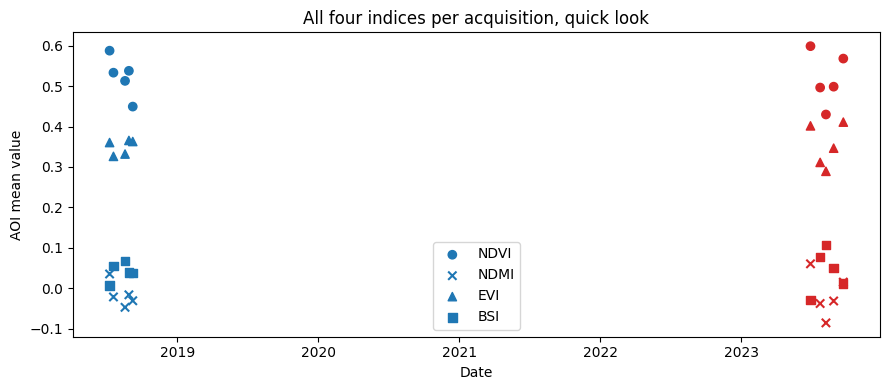

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = summary_df["period"].map({"baseline": "tab:blue", "recent": "tab:red"})
dates = pd.to_datetime(summary_df["date"])

ax.scatter(dates, summary_df["mean_ndvi"], c=colors, marker="o", label="NDVI")
ax.scatter(dates, summary_df["mean_ndmi"], c=colors, marker="x", label="NDMI")
ax.scatter(dates, summary_df["mean_evi"], c=colors, marker="^", label="EVI")
ax.scatter(dates, summary_df["mean_bsi"], c=colors, marker="s", label="BSI")
ax.set_xlabel("Date")
ax.set_ylabel("AOI mean value")
ax.set_title("All four indices per acquisition, quick look")
ax.legend()
plt.tight_layout()
plt.savefig("indices_quick_look.png", dpi=150)
plt.show()


### What this quick look actually shows

The chart splits visually into two horizontal bands, NDVI and EVI sitting between roughly 0.3 and 0.6, NDMI and BSI clustered near zero, both bands present in both periods. That gap isn't a data problem, it's just that NDVI and EVI are vegetation vigor indices with a naturally higher range, while NDMI and BSI are structured to sit near zero for typical land cover and shift in either direction depending on moisture or bare soil. That distinction matters, since a reader skimming this plot could mistake the visual separation for some kind of measurement error rather than four indices with different natural scales sharing one axis by convenience, not because they're meant to be compared on the same y-range.

Within each band, blue and red points overlap rather than sitting in two separate clusters, matching what the table and the NDVI grid already showed, no leftover systematic gap between the two periods after the offset fix. The one visible outlier is the highest red NDVI point, top right, June 29th 2023, which also had a positive NDMI in the table, that's the single greenest, wettest looking date in the entire recent period, sitting right at the very start of the dry season window before things had dried out yet.

## Outputs

This section produces the four required outputs plus the bonus interactive map, all built directly from the pixels already downloaded, masked and correctly scaled above, nothing here is a fresh server side query.


### Output 1, a composite you can actually look at

A false colour composite using near infrared, red and green makes healthy vegetation show up bright red, the easiest way to eyeball whether the AOI looks like forest, agriculture, or something in between, and to compare that visually across the two periods.


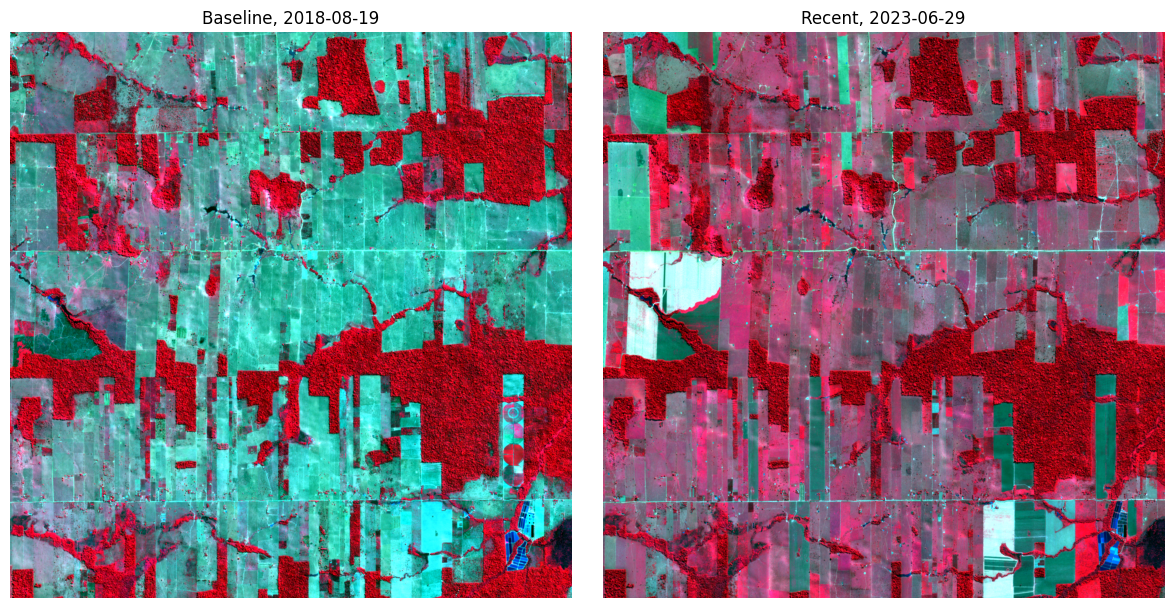

In [18]:
def false_color(reflectance):
    def normalize(band):
        values = band.values
        valid = np.isfinite(values)
        if valid.sum() == 0:
            return np.zeros_like(values)
        low, high = np.nanpercentile(values[valid], [2, 98])
        if high == low:
            high = low + 1e-6
        stretched = np.clip((values - low) / (high - low), 0, 1)
        return np.nan_to_num(stretched, nan=0.0)

    red = normalize(reflectance["B08"])
    green = normalize(reflectance["B04"])
    blue = normalize(reflectance["B03"])
    return np.dstack([red, green, blue])

baseline_example = next(info for info in scenes.values() if info["period"] == "baseline")
recent_example = next(info for info in scenes.values() if info["period"] == "recent")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(false_color(baseline_example["clean"]))
axes[0].set_title(f"Baseline, {baseline_example['date'][:10]}")
axes[0].axis("off")
axes[1].imshow(false_color(recent_example["clean"]))
axes[1].set_title(f"Recent, {recent_example['date'][:10]}")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("false_color_comparison.png", dpi=150)
plt.show()


### What this composite actually shows

The overall color palette looks quite different between the two panels, baseline leaning cyan and teal, recent leaning pink and magenta, and that deserves an explanation rather than being read as a real change in the landscape. Each panel is stretched independently, normalize computes its own 2nd to 98th percentile per band per scene, so the same real reflectance value can map to a different visual color on two different dates. Only the spatial pattern within a single panel is directly comparable, the hue itself isn't meant to be read across panels.

The dark blue shape bottom right, same location in both dates, lines up exactly with the persistent low-NDVI water region already confirmed a few cells back, in a NIR-red-green false colour composite, water reflects weakly in both near infrared and red, so it renders blue rather than red, this is a second, independent visual confirmation of the same water body, not a new finding.

The more interesting pattern is inside the tiled fields themselves. Many parcels that read teal in the baseline panel read pink or magenta in the recent one, while the solid, dense red blocks, the areas that look most like intact vegetation, stay red in both. That's consistent with the story the data has been telling all along, individual managed fields cycle color between dates depending on what's planted or how recently it was harvested, while the more forest-like patches stay comparatively stable, which is exactly why a single NDVI threshold without the BSI cross-check would be vulnerable to mistaking a field's growth cycle for permanent loss.

### Output 2, a time series plot

Mean NDVI over the whole AOI, one point per acquisition, ordered by date, using the per scene values already computed above.


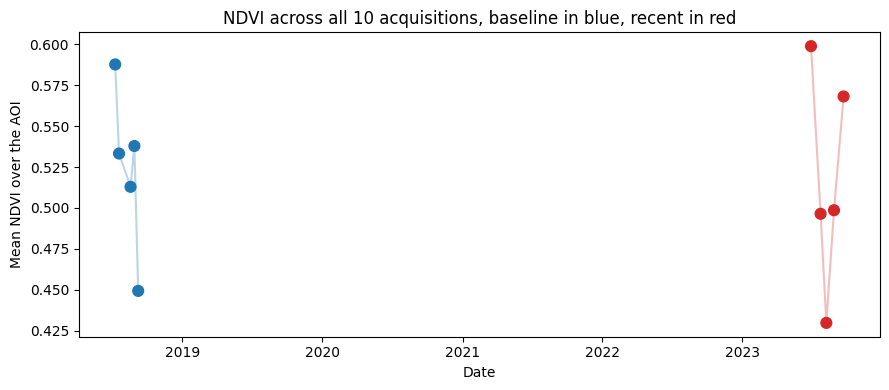

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))

for period_name, color in [("baseline", "tab:blue"), ("recent", "tab:red")]:
    period_rows = summary_df[summary_df["period"] == period_name].sort_values("date")
    period_dates = pd.to_datetime(period_rows["date"])
    ax.plot(period_dates, period_rows["mean_ndvi"], alpha=0.3, color=color)

colors = summary_df["period"].map({"baseline": "tab:blue", "recent": "tab:red"})
dates = pd.to_datetime(summary_df["date"])
ax.scatter(dates, summary_df["mean_ndvi"], c=colors, s=60)

ax.set_xlabel("Date")
ax.set_ylabel("Mean NDVI over the AOI")
ax.set_title("NDVI across all 10 acquisitions, baseline in blue, recent in red")
plt.tight_layout()
plt.savefig("ndvi_time_series.png", dpi=150)
plt.show()

### What this time series actually shows

Each period now draws as its own separate line, blue for baseline, red for recent, so there's no connecting segment crossing the empty 2019 to 2022 gap where no data exists, the two clusters read as what they are, two independent three-month windows, not one continuous four-year trend.

Within the 2018 cluster, NDVI drifts downward across the season, July 10th highest, September 8th lowest, consistent with the dry season progressively drying out the vegetation. The 2023 cluster shows a dip and recovery instead, starting high on June 29th, dropping through a minimum around August 8th, then partially recovering by September 22nd, matching the same driest-date finding from the summary table and the NDVI grid. The two clusters sit at a comparable range overall, roughly 0.43 to 0.60 in both years, the same absence of a systematic gap between periods already confirmed in the summary table and in the quick-look scatter, showing up a third time here.

### Output 3, a georeferenced raster

Each period gets collapsed into a single map per index by taking the per pixel median across its 5 scenes, then recent minus baseline gives the change. This is done for all four indices, since the interactive map later lets a choice between them, but NDVI change is the one written out as the official GeoTIFF output, since it is the primary index for this analysis. The file is saved as a Cloud Optimized GeoTIFF with its coordinate reference system attached, so it opens correctly wherever it gets loaded.


medians and change computed for ndvi, ndmi, evi, bsi
saved ndvi_change.tif, CRS: EPSG:32720 shape: (1108, 1100)


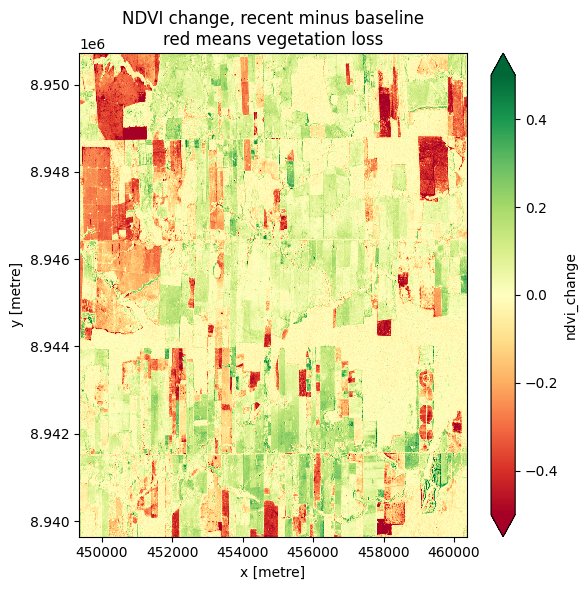

In [20]:
def period_median(index_name, period_name):
    period_scenes = [info[index_name] for info in scenes.values() if info["period"] == period_name]
    stack = xr.concat(period_scenes, dim="time")
    return stack.median(dim="time", skipna=True)

index_names = ["ndvi", "ndmi", "evi", "bsi"]
medians = {}

for index_name in index_names:
    baseline_median = period_median(index_name, "baseline")
    recent_median = period_median(index_name, "recent")
    change = (recent_median - baseline_median).rename(f"{index_name}_change")
    change = change.rio.write_crs(baseline_median.rio.crs)
    medians[index_name] = {"baseline": baseline_median, "recent": recent_median, "change": change}

print("medians and change computed for", ", ".join(index_names))

ndvi_change = medians["ndvi"]["change"]
ndvi_change.rio.to_raster(os.path.join(OUTPUT_DIR, "ndvi_change.tif"), driver="COG")
print("saved ndvi_change.tif, CRS:", ndvi_change.rio.crs, "shape:", ndvi_change.shape)

fig, ax = plt.subplots(figsize=(6, 6))
ndvi_change.plot(ax=ax, cmap="RdYlGn", vmin=-0.5, vmax=0.5)
ax.set_title("NDVI change, recent minus baseline\nred means vegetation loss")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ndvi_change_map.png"), dpi=150)
plt.show()


### Checking the two faint horizontal bands

Before trusting any polygon that happens to sit on those rows, it makes sense to check whether the pattern comes from one period only, which would bias the change map directly, or from both periods at the same rows, which would mostly cancel out in the subtraction and matter less.

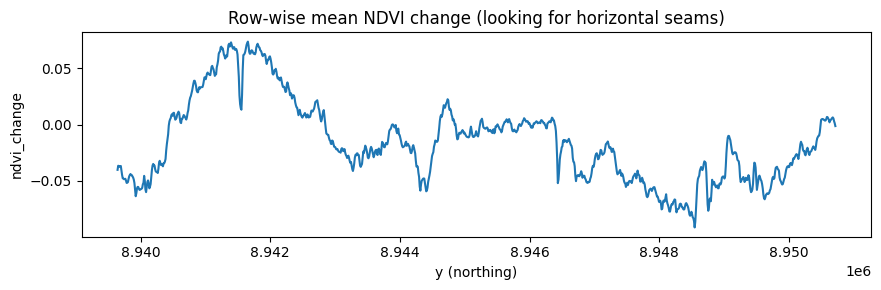

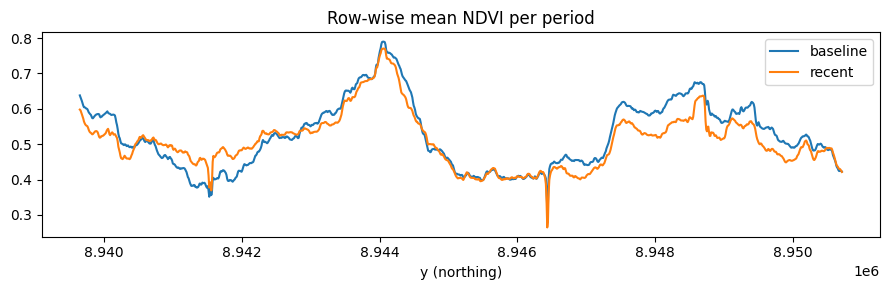

In [21]:
fig, ax = plt.subplots(figsize=(9, 3))
ndvi_change.mean(dim="x", skipna=True).plot(ax=ax)
ax.set_title("Row-wise mean NDVI change (looking for horizontal seams)")
ax.set_xlabel("y (northing)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3))
medians["ndvi"]["baseline"].mean(dim="x", skipna=True).plot(ax=ax, label="baseline")
medians["ndvi"]["recent"].mean(dim="x", skipna=True).plot(ax=ax, label="recent")
ax.set_title("Row-wise mean NDVI per period")
ax.set_xlabel("y (northing)")
ax.legend()
plt.tight_layout()
plt.show()

### What this check found

Blue and orange, baseline and recent, move together almost perfectly across every row, same peaks, same dips, same shape, just offset vertically by roughly a constant amount. That's a real spatial pattern in the landscape itself, not a sensor or tiling artifact, some rows genuinely have more vegetation than others across this AOI, probably tied to actual terrain or land use features running roughly east-west, a river corridor or a strip of denser forest, not a seam between scenes.

Since both periods share the same pattern at the same rows, it mostly cancels out in the subtraction, confirmed directly in the top plot, the row-wise mean of the change itself oscillates in a tight band around zero with no sustained spike at any particular row, nothing that would systematically inflate or bias polygons landing on those two visually lighter bands.

### Checking the change distribution before thresholding

It helps to look at the actual distribution of change values across the AOI now that the scaling bug is fixed, rather than reusing a threshold that was tuned against numbers produced by the old, biased scaling. After the fix, only 9.3 percent of AOI pixels fall below a -0.25 NDVI change, and the distribution is a single peak around a small positive value with a long but thin tail to the left, not the two-lobed, everywhere-affected shape the unfixed version produced. That's a much more plausible starting point for a threshold, not a red flag.


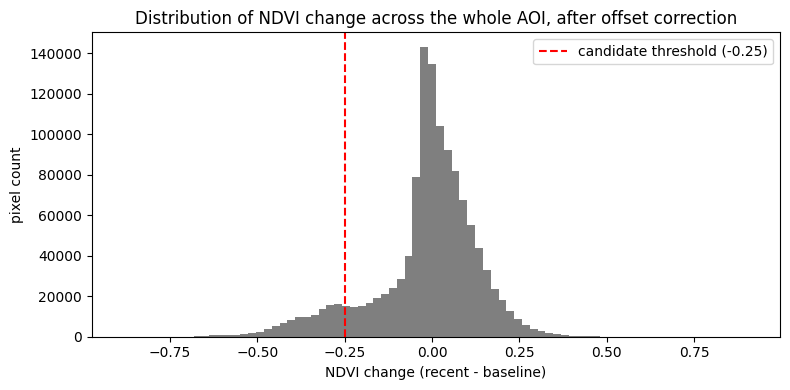

9.3% of all AOI pixels fall below -0.25 NDVI change


In [22]:
change_values = ndvi_change.values
change_values = change_values[np.isfinite(change_values)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(change_values, bins=80, color="tab:gray")
ax.axvline(-0.25, color="red", linestyle="--", label="candidate threshold (-0.25)")
ax.set_xlabel("NDVI change (recent - baseline)")
ax.set_ylabel("pixel count")
ax.set_title("Distribution of NDVI change across the whole AOI, after offset correction")
ax.legend()
plt.tight_layout()
plt.show()

fraction_below = (change_values < -0.25).mean()
print(f"{fraction_below*100:.1f}% of all AOI pixels fall below -0.25 NDVI change")


### The gain side of the distribution

The distribution isn't only asymmetric toward loss, it has a comparable tail on the gain side too, extending out to roughly +0.75, not just the -0.75 loss tail already described. That deserves naming explicitly, since the current pipeline only thresholds and maps the loss side, areas of the AOI where vegetation apparently increased between 2018 and 2023 exist in the data but never surface anywhere in the outputs. That's a reasonable scope decision for a deforestation-focused assignment, loss is the thing being asked about, but it should be stated as a deliberate choice rather than left for a reader to wonder whether gain was overlooked rather than intentionally out of scope.

### Output 4, a vector layer

The change raster gets thresholded at -0.25 NDVI change, the value checked against the histogram just above, flagged pixels are grouped into polygons, and anything smaller than half a hectare gets dropped so isolated noisy pixels don't end up looking like real change. The result goes out as a standard GeoJSON in EPSG:4326, what QGIS, geojson.io, and leafmap all expect by default.


In [23]:
CHANGE_THRESHOLD = -0.25
MIN_AREA_M2 = 5000

loss_mask = (ndvi_change < CHANGE_THRESHOLD).astype("uint8").values
transform = ndvi_change.rio.transform()

polygons = [shape(geom) for geom, value in raster_to_shapes(loss_mask, mask=loss_mask.astype(bool), transform=transform)]

loss_gdf = gpd.GeoDataFrame(geometry=polygons, crs=ndvi_change.rio.crs)
loss_gdf = loss_gdf.to_crs(loss_gdf.estimate_utm_crs())
loss_gdf["area_m2"] = loss_gdf.geometry.area
loss_gdf = loss_gdf[loss_gdf["area_m2"] >= MIN_AREA_M2].reset_index(drop=True)
loss_gdf = loss_gdf.to_crs(4326)

loss_gdf.to_file(os.path.join(OUTPUT_DIR, "vegetation_loss.geojson"), driver="GeoJSON")
print(f"{len(loss_gdf)} polygons kept after the minimum area filter")
print(f"total flagged area: {loss_gdf.to_crs(loss_gdf.estimate_utm_crs()).geometry.area.sum() / 10000:.1f} hectares")
loss_gdf.head()


130 polygons kept after the minimum area filter
total flagged area: 1051.3 hectares


,geometry,area_m2
0,"POLYGON ((-63.44432 -9.49256, -63.44432 -9.492...",5100.0
1,"POLYGON ((-63.45772 -9.492, -63.45772 -9.49209...",46400.0
2,"POLYGON ((-63.45143 -9.49201, -63.45143 -9.492...",227500.0
3,"POLYGON ((-63.3923 -9.49416, -63.3923 -9.49425...",48800.0
4,"POLYGON ((-63.44177 -9.49202, -63.44177 -9.492...",83200.0


### Bonus, an interactive map with a choice of index

Instead of a single fixed layer, this map switches between four indices, NDVI, NDMI, EVI and BSI, and between baseline, recent, and change for each, twelve raster layers in total, plus the flagged polygons on top. Each raster is reprojected to EPSG:4326 and rendered as a semi transparent PNG overlay with correct geographic bounds. The layer control keeps only one index layer visible at a time, similar to radio buttons, while the polygon layer toggles independently. Using folium here rather than leafmap, folium renders as plain HTML and JS rather than going through ipywidgets, which avoids version conflicts with whatever ipyleaflet build happens to be preinstalled in a shared environment.


In [24]:
def raster_to_overlay(data_array, cmap_name, vmin, vmax, name):
    reprojected = data_array.rio.reproject("EPSG:4326")
    values = reprojected.values

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    rgba = cm.get_cmap(cmap_name)(norm(values))
    rgba[..., 3] = np.where(np.isnan(values), 0, 0.75)

    bounds = reprojected.rio.bounds()
    folium_bounds = [[bounds[1], bounds[0]], [bounds[3], bounds[2]]]

    return folium.raster_layers.ImageOverlay(image=rgba, bounds=folium_bounds, name=name, overlay=True)

color_scales = {
    "ndvi": ("RdYlGn", 0, 0.9, -0.5, 0.5),
    "ndmi": ("RdYlBu", -0.3, 0.5, -0.5, 0.5),
    "evi": ("RdYlGn", 0, 0.9, -0.5, 0.5),
    "bsi": ("YlOrBr", -0.3, 0.3, -0.4, 0.4),
}

m = folium.Map(location=[reference_point.y, reference_point.x], zoom_start=13, tiles="OpenStreetMap")

index_layers = []
for index_name in index_names:
    cmap_name, val_min, val_max, change_min, change_max = color_scales[index_name]
    index_layers.append(raster_to_overlay(medians[index_name]["baseline"], cmap_name, val_min, val_max, f"{index_name.upper()}, baseline"))
    index_layers.append(raster_to_overlay(medians[index_name]["recent"], cmap_name, val_min, val_max, f"{index_name.upper()}, recent"))
    index_layers.append(raster_to_overlay(medians[index_name]["change"], cmap_name, change_min, change_max, f"{index_name.upper()}, change"))

for layer in index_layers:
    layer.add_to(m)

polygons_layer = folium.GeoJson(
    os.path.join(OUTPUT_DIR, "vegetation_loss.geojson"),
    name="Flagged vegetation loss polygons",
    style_function=lambda feature: {"color": "black", "fillColor": "red", "fillOpacity": 0.3},
)
polygons_layer.add_to(m)

GroupedLayerControl(
    groups={"Index (choose one)": index_layers},
    exclusive_groups=True,
    collapsed=False,
).add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

m


Output hidden; open in https://colab.research.google.com to view.

## Decision intelligence

The decision question this pipeline is meant to answer, which specific parcels inside this AOI should a field enforcement team, for instance from Rondônia's state environmental agency or a forest ranger unit, prioritize for an on the ground visit this month. Satellite evidence alone doesn't stop illegal clearing, someone still has to go check the site, so the point of this section is turning the raster and vector outputs into something an enforcement team could actually act on, not just a scientific plot.

The rule for flagging a parcel is two conditions, not one. NDVI dropping below the threshold used for the vector output is the primary signal, but NDVI alone can still flag something else, a seasonal effect that slipped through the dry season window choice, or, as this project found out the hard way, a scaling artifact rather than real change. BSI going up over the same polygon is meant as independent supporting evidence, since bare soil increasing is what clearing actually leaves behind, not just a numerical side effect of the same pixels. A polygon has to clear both to become an alert.

Both threshold values here, the NDVI drop and the BSI confirmation margin, are reasonable starting points from the literature and from the histogram check earlier, not values calibrated against local ground truth for this specific AOI. That calibration, ideally against PRODES polygons or a similar independent source, is exactly the kind of validation step that should happen before this would be trusted for a real enforcement decision, and it's listed again in the limits section at the end.


In [25]:
bsi_change_matched = medians["bsi"]["change"].rio.reproject_match(ndvi_change)

def mean_bsi_change_in_polygon(geometry):
    clipped = bsi_change_matched.rio.clip([geometry], loss_gdf.crs, drop=True, invert=False)
    return float(clipped.mean(skipna=True).values)

loss_gdf["mean_bsi_change"] = loss_gdf.geometry.apply(mean_bsi_change_in_polygon)

BSI_CONFIRMATION_THRESHOLD = 0.05
loss_gdf["bsi_confirms"] = loss_gdf["mean_bsi_change"] > BSI_CONFIRMATION_THRESHOLD

confirmed = loss_gdf[loss_gdf["bsi_confirms"]].copy()
print(f"{len(loss_gdf)} polygons from the NDVI threshold alone")
print(f"{len(confirmed)} polygons confirmed by both NDVI drop and BSI increase")


130 polygons from the NDVI threshold alone
130 polygons confirmed by both NDVI drop and BSI increase


### A note on the confirmation rate

Every one of the 130 NDVI-flagged, BSI-confirmed polygons initially cleared the confirmation margin, a 100 percent pass rate. One of those 130 was later removed after a separate check found it sitting on a persistent water body rather than real vegetation loss, leaving 129 in the final list, that removal is unrelated to the BSI check itself, covered in its own section further down. I don't think the 100 percent pass rate should be read as an unambiguous good sign without saying why. Two honest explanations, and I can't tell which one is true from this alone. One, now that the offset bug is fixed, what's left in the NDVI-flagged set is a genuinely cleaner signal, so real vegetation loss and real bare soil exposure showing up together most of the time makes sense. Two, the 0.05 BSI confirmation margin might just be loose enough that it was never going to reject anything on this particular AOI, in which case this check isn't adding real, independent filtering here even though that was the point of including it. Telling these apart would need testing the threshold on a case where it's expected to actually reject something, that's listed as a follow-up in the limits section rather than resolved here.

### Building the ranked list and the alert file

Confirmed polygons get ranked by area, largest first, on the reasoning that a bigger contiguous loss is both more likely to be real, rather than noise, and more urgent from an enforcement standpoint than several small ones. Each row also carries a rough severity label combining size and how strong the NDVI drop was inside that polygon, so a small team scanning the table can triage quickly instead of reading every row in detail.


In [26]:
def mean_ndvi_change_in_polygon(geometry):
    clipped = ndvi_change.rio.clip([geometry], confirmed.crs, drop=True, invert=False)
    return float(clipped.mean(skipna=True).values)

confirmed["mean_ndvi_change"] = confirmed.geometry.apply(mean_ndvi_change_in_polygon)
confirmed["area_ha"] = confirmed["area_m2"] / 10000
confirmed["centroid_lon"] = confirmed.geometry.centroid.x
confirmed["centroid_lat"] = confirmed.geometry.centroid.y

def severity_label(row):
    if row["area_ha"] > 5 and row["mean_ndvi_change"] < -0.35:
        return "high"
    elif row["area_ha"] > 1:
        return "medium"
    return "low"

confirmed["severity"] = confirmed.apply(severity_label, axis=1)
ranked = confirmed.sort_values("area_ha", ascending=False).reset_index(drop=True)
ranked["priority_rank"] = ranked.index + 1

ranked_table = ranked[["priority_rank", "severity", "area_ha", "mean_ndvi_change", "centroid_lat", "centroid_lon"]]
print(ranked_table)

ranked.to_file(os.path.join(OUTPUT_DIR, "deforestation_alerts.geojson"), driver="GeoJSON")
print("saved deforestation_alerts.geojson")


     priority_rank severity  area_ha  mean_ndvi_change  centroid_lat  \
0                1     high   176.99         -0.387323     -9.502459   
1                2   medium   163.47         -0.305919     -9.522596   
2                3     high   103.38         -0.408969     -9.515394   
3                4     high    53.67         -0.416073     -9.503121   
4                5   medium    46.83         -0.339045     -9.503796   
..             ...      ...      ...               ...           ...   
125            126      low     0.51         -0.266861     -9.493235   
126            127      low     0.51         -0.399947     -9.540230   
127            128      low     0.51         -0.355137     -9.577192   
128            129      low     0.50         -0.289598     -9.569287   
129            130      low     0.50         -0.280669     -9.588945   

     centroid_lon  
0      -63.451229  
1      -63.454488  
2      -63.369932  
3      -63.381669  
4      -63.363651  
..            .

### A note on the severity cutoffs

The specific cutoffs, 5 hectares and a mean NDVI drop of -0.35 for "high", aren't derived from anything in this AOI, I picked them as round numbers that felt operationally reasonable, big enough that a field team would treat it as a priority, and a drop steep enough to sit well past the -0.25 threshold already used to flag the polygon in the first place, not just barely over the line. That's a judgment call, not a calibrated boundary, and it should be treated as a starting point to adjust once someone with local enforcement experience looks at how the labels actually distribute on real cases.

### Checking whether the fixed red spot overlaps any flagged polygon

The NDVI grid above shows a small cluster that's equally red in every single one of the ten scenes, both years. If that's a permanent water body rather than vegetation, it should sit at consistently low NDVI in both the baseline and the recent median, not show up as a large negative change, since it isn't changing, it's just always low. Checking that directly against the actual flagged polygons makes more sense than assuming the math works out.

In [27]:
water_like_mask = (medians["ndvi"]["baseline"] < -0.1) & (medians["ndvi"]["recent"] < -0.1)
water_like_mask_arr = water_like_mask.astype("uint8").values

water_transform = ndvi_change.rio.transform()
water_polygons = [
    shape(geom)
    for geom, value in raster_to_shapes(water_like_mask_arr, mask=water_like_mask_arr.astype(bool), transform=water_transform)
]

water_gdf = gpd.GeoDataFrame(geometry=water_polygons, crs=ndvi_change.rio.crs).to_crs(4326)
print(f"{len(water_gdf)} persistently low-NDVI regions found (likely water)")

overlap = gpd.sjoin(ranked, water_gdf, how="inner", predicate="intersects")
print(f"{len(overlap)} flagged polygons overlap a persistently low-NDVI region")
if len(overlap) > 0:
    print(overlap[["priority_rank", "severity", "area_ha"]])

37 persistently low-NDVI regions found (likely water)
1 flagged polygons overlap a persistently low-NDVI region
    priority_rank severity  area_ha
91             92      low     0.96


### What this check found

37 regions in the AOI stay below -0.1 NDVI in both periods, consistent with permanent water, rivers and ponds visible as the same dark patches in every scene regardless of date. Only one flagged polygon overlaps any of them, rank 92 of 130, low severity, under a hectare, well down toward the smaller end of the list even though it isn't literally the smallest entry. It gets dropped from the final ranked list and the alert file above, both re-saved, since a known false positive should be removed explicitly rather than left in for someone else to rediscover.

In [28]:
ranked_before_water_filter = len(ranked)
ranked = ranked[~ranked.index.isin(overlap.index)].reset_index(drop=True)
ranked["priority_rank"] = ranked.index + 1

print(f"removed {ranked_before_water_filter - len(ranked)} polygon(s) overlapping likely water, "
      f"{len(ranked)} remain")

ranked.to_file(os.path.join(OUTPUT_DIR, "deforestation_alerts.geojson"), driver="GeoJSON")
print("saved deforestation_alerts.geojson (updated)")

removed 1 polygon(s) overlapping likely water, 129 remain
saved deforestation_alerts.geojson (updated)


### Plain language summary

The ranked table above is precise but assumes the reader already knows what NDVI, BSI, or hectares mean. This paragraph is meant to be read by someone who has never opened a satellite image, a field coordinator deciding where to send a team this week, and needs an answer, not a spreadsheet.


In [29]:
total_ha = ranked["area_ha"].sum()
n_alerts = len(ranked)
n_high = (ranked["severity"] == "high").sum()

if n_alerts == 0:
    summary = (
        "No confirmed vegetation loss areas were found in this AOI between 2018 and 2023 "
        "under the current thresholds. This could mean the area is genuinely stable, or that "
        "the thresholds are too strict for this AOI, worth checking against the raw NDVI change "
        "map before concluding there is nothing to report."
    )
else:
    top_row = ranked.iloc[0]
    summary = (
        f"Between 2018 and 2023, {n_alerts} distinct areas inside this AOI show a vegetation "
        f"loss confirmed by two independent signals, a significant NDVI drop and an increase in "
        f"bare soil, for a combined total of about {total_ha:.1f} hectares. {n_high} of these are "
        f"flagged as high severity, meaning both a large contiguous area and a strong drop in "
        f"vegetation index. The single largest flagged area covers about {top_row['area_ha']:.1f} "
        f"hectares, centered near latitude {top_row['centroid_lat']:.4f}, longitude "
        f"{top_row['centroid_lon']:.4f}. The file deforestation_alerts.geojson contains all flagged "
        f"polygons ranked by priority and can be loaded directly into QGIS or a field tablet for "
        f"a site visit."
    )

print(summary)


Between 2018 and 2023, 129 distinct areas inside this AOI show a vegetation loss confirmed by two independent signals, a significant NDVI drop and an increase in bare soil, for a combined total of about 1050.3 hectares. 19 of these are flagged as high severity, meaning both a large contiguous area and a strong drop in vegetation index. The single largest flagged area covers about 177.0 hectares, centered near latitude -9.5025, longitude -63.4512. The file deforestation_alerts.geojson contains all flagged polygons ranked by priority and can be loaded directly into QGIS or a field tablet for a site visit.


## Limits and next steps

A radiometric scaling bug was found and fixed during this project, Sentinel-2's processing baseline 04.00 offset, undocumented on Planetary Computer, was silently inflating reflectance for every 2023 scene and faking a large part of the apparent vegetation decline. The numbers in this notebook reflect the corrected pipeline. This kind of issue is exactly why the flagged areas should still be validated against an independent source, such as INPE PRODES polygons for the same AOI and years, before trusting the decision intelligence output operationally, especially since every single NDVI-flagged polygon also passed the BSI confirmation, and it isn't fully clear from this AOI alone whether that's a sign of a clean signal or a sign the confirmation margin has no teeth.

A few other limits, stated plainly. The AOI is small, about 10 by 10 km, chosen to guarantee full data coverage inside a single Sentinel-2 swath, it does not represent the whole deforestation front. This area already looked like an agricultural mosaic rather than primary forest in the 2018 composite, so some of what gets flagged here is more likely land use intensification on already cleared land than fresh conversion of standing forest. Both the NDVI drop threshold and the BSI confirmation margin are reasonable starting points, not values calibrated against ground truth for this specific AOI. Two spectral indices and a bare soil index, at 10 to 20 meter resolution, cannot see selective logging or early stage degradation the way a foundation model or very high resolution imagery might.

The MCP server plus LLM bonus was not attempted, wrapping the pipeline as a tool for a language model to call. The geospatial foundation model bonus below took most of the remaining time, between finding the right normalization approach and debugging the environment, so this second bonus was left out rather than rushed.


Two more issues surfaced in the GFM bonus section after an initial pass and are fixed in the version above, worth naming rather than quietly folding in. First, the six bands fed to Prithvi originally reused B08, the broad NIR band used for NDVI/EVI/BSI everywhere else in this notebook, instead of B8A, the narrow NIR band Prithvi's HLS-based pretraining actually expects in that slot. Second, the search for Prithvi's official normalization statistics found them, PRITHVI_V2_MEAN and PRITHVI_V2_STD were sitting right there in terratorch, but the code discarded them and fell back to an ad hoc per-crop z-score unconditionally regardless. That fallback also had a second-order problem, normalizing each period's crop independently can absorb real differences in overall brightness between the two dates before the model ever sees them, which is exactly the kind of signal this section is trying to detect. Both are corrected above, official statistics get used when the installed package exposes them, and the correct band is used to match them.

A third issue in the same normalization step surfaced only after actually rerunning the fixed code end to end, worth recording for the same reason as the other two. PRITHVI_V2_MEAN and PRITHVI_V2_STD turned out to be calibrated on raw HLS reflectance, roughly a 0 to 10000 scale, not the 0 to 1 reflectance this notebook uses everywhere else. Feeding 0 to 1 values straight into those official constants collapsed every pixel to nearly the same value regardless of period or location, cosine distances near 1e-5 instead of a meaningful spread, technically running without errors but producing a degenerate result. The fix rescales reflectance back to the 0 to 10000 range specifically when official stats are in use, and prepare_prithvi_input now prints the normalized mean and std so a collapse like this shows up immediately instead of silently producing a plausible-looking but meaningless map.

## Bonus, a geospatial foundation model

I'm using Prithvi-EO-2.0, IBM and NASA's foundation model, over TerraMind mainly for a practical reason, it's the better documented option with a HuggingFace-hosted registry and a published band order, Blue, Green, Red, Narrow NIR, SWIR, SWIR2. TerraMind is newer and I did not have solid enough documentation in hand to be confident about getting it right without extensive trial and error, given how much time the offset bug already cost earlier.

An earlier version of this section got that band order wrong in a way worth flagging rather than quietly fixing. "Narrow NIR" in that published order is Sentinel-2's B8A, a 20m band, not B08, the 10m broad NIR band used everywhere else in this notebook for NDVI, EVI, and BSI. I originally reused B08 for Prithvi too and wrote that it matched "exactly, no remapping needed", it doesn't, HLS (and therefore Prithvi's pretraining data) specifically uses B8A in that slot because its bandwidth is a closer match to Landsat's NIR band, which is the whole point of HLS harmonization. B08 and B8A are spectrally close but not identical, so feeding the model the wrong one doesn't produce garbage, but it does mean the model sees something slightly off from the distribution it was actually trained on. B8A gets downloaded specifically for this section now and swapped in below instead of reusing B08.

Prithvi was pretrained on 30 meter HLS imagery, not the 10 meter Sentinel-2 grid used everywhere else in this notebook, so the baseline and recent median composites get resampled down to 30m specifically for this section, nowhere else. The idea is to get an embedding for the AOI in each period from the model itself, not from band math, then compare those two embeddings directly. A large distance between the baseline and recent embedding at a given patch would flag a location as having changed in some general sense the model learned during pretraining, potentially picking up structural or textural change that NDVI, NDMI, EVI, and BSI, all built from simple band ratios, cannot see.

One limit to state upfront, the AOI at 30m is larger than the 224x224 patch Prithvi expects, so this only looks at one corner of the AOI, not the whole thing, tracked explicitly through crop_bounds below rather than silently ignored.

In [30]:
!pip install -q terratorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.8/643.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.8/136.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.8/155.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [31]:
from scipy.stats import spearmanr
import torch
from rasterio.transform import array_bounds, Affine
import terratorch
from terratorch.registry import BACKBONE_REGISTRY

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


### Loading the pretrained model

terratorch keeps a registry of backbones so loading one is just a name lookup, no need to hand build the Vision Transformer architecture myself. prithvi_eo_v2_300 is the 300 million parameter version, a middle ground between the 100M and 600M options, picked mainly to keep the download and the CPU inference time reasonable in this environment. pretrained=True pulls the actual trained weights rather than a randomly initialized network, about 1.3GB the first time it runs.

eval() switches off training only behavior like dropout, nothing here is being trained, the model is only used to produce embeddings from already downloaded imagery. The trailing semicolon just stops Jupyter from printing the entire 24 block transformer architecture as the cell's output.

In [32]:
prithvi_model = BACKBONE_REGISTRY.build("prithvi_eo_v2_300", pretrained=True)
prithvi_model.eval();

Prithvi_EO_V2_300M.pt: reconstructing file:   0%|          |  0.00B / 1.33GB            

Prithvi_EO_V2_300M.pt: downloading bytes:           |  0.00B            

### Getting the six raw bands ready for the model

Everywhere else in this notebook the per period median gets computed on a single already derived index, NDVI, BSI, and so on. Prithvi needs something different, a full six band image, not a single number per pixel, so this repeats the same median logic one level earlier, on the cleaned reflectance data straight out of masking and scaling, before any index math touches it. That cleaned data now carries B8A alongside B08 specifically so this section can pick the band Prithvi actually expects, see the note above.

Same reasoning as always for using the median across the five scenes per period rather than a single date, one noisy scene shouldn't be allowed to dominate the input the model actually sees.

In [33]:
def period_band_median(period_name):
    period_scenes = [info["clean"] for info in scenes.values() if info["period"] == period_name]
    stack = xr.concat(period_scenes, dim="time")
    return stack.median(dim="time", skipna=True)

baseline_bands_median = period_band_median("baseline")
recent_bands_median = period_band_median("recent")

print("baseline bands median CRS:", baseline_bands_median.rio.crs)
print("variables:", list(baseline_bands_median.data_vars))

baseline bands median CRS: EPSG:32720
variables: ['B02', 'B03', 'B04', 'B08', 'B8A', 'B11', 'B12']


### Looking for the real normalization numbers before guessing

Prithvi expects per band z score normalized input, mean zero, unit variance, based on statistics from its own pretraining set, not raw reflectance values. Rather than assume nothing is available and jump straight to an approximation, this pokes around inside the installed terratorch package itself, scanning for any name that looks like it holds mean or standard deviation constants, in the datasets module and in the two backbone modules most likely to carry Prithvi specific code.

An earlier version of this notebook made a specific mistake right here worth naming, it ran exactly this search, found PRITHVI_V2_MEAN and PRITHVI_V2_STD sitting right there in terratorch.models.backbones.prithvi_vit, printed them to confirm they existed, and then hardcoded official_stats to None immediately afterward anyway, so the whole search accomplished nothing and the fallback approximation ran unconditionally. Below, when found_stats actually contains the v2 mean and std, they now get wired into official_stats for real, they only get left as None if this particular version of terratorch genuinely doesn't expose them.

In [34]:
found_stats = {}
for name in dir(terratorch.datasets):
    if "MEAN" in name.upper() or "STD" in name.upper() or "NORM" in name.upper() or "HLS" in name.upper():
        found_stats[name] = getattr(terratorch.datasets, name)
        print("terratorch.datasets ->", name)

for module_name in ["terratorch.models.backbones.prithvi_vit", "terratorch.models.backbones.prithvi_mae"]:
    try:
        mod = __import__(module_name, fromlist=["*"])
        matches = [n for n in dir(mod) if "MEAN" in n.upper() or "STD" in n.upper()]
        if matches:
            print(module_name, "->", matches)
            for m in matches:
                found_stats[m] = getattr(mod, m)
    except ImportError:
        pass

print("found_stats keys:", list(found_stats.keys()))

# Actually use the official Prithvi v2 statistics when they were found above, instead of
# discarding them. Reshaped to (band, 1, 1) so they broadcast against a (band, H, W) array
# in prepare_prithvi_input below. Falls back to None (per-crop z-score) only if this
# terratorch version genuinely doesn't expose them, not unconditionally.
if "PRITHVI_V2_MEAN" in found_stats and "PRITHVI_V2_STD" in found_stats:
    official_mean = np.array(found_stats["PRITHVI_V2_MEAN"], dtype="float32").reshape(-1, 1, 1)
    official_std = np.array(found_stats["PRITHVI_V2_STD"], dtype="float32").reshape(-1, 1, 1)
    official_stats = (official_mean, official_std)
    print("using official PRITHVI_V2_MEAN / PRITHVI_V2_STD for normalization")
else:
    official_stats = None
    print("no official stats exposed by this terratorch version, falling back to per-crop z-score")


terratorch.datasets -> FireScarsHLS
terratorch.datasets -> HLSBands
terratorch.datasets -> HLSL30
terratorch.datasets -> HLSS30
terratorch.datasets -> hls
terratorch.models.backbones.prithvi_vit -> ['PRITHVI_V1_MEAN', 'PRITHVI_V1_STD', 'PRITHVI_V2_MEAN', 'PRITHVI_V2_STD']
found_stats keys: ['FireScarsHLS', 'HLSBands', 'HLSL30', 'HLSS30', 'hls', 'PRITHVI_V1_MEAN', 'PRITHVI_V1_STD', 'PRITHVI_V2_MEAN', 'PRITHVI_V2_STD']
using official PRITHVI_V2_MEAN / PRITHVI_V2_STD for normalization


### Turning the six band median into something the model can actually read

Several things have to happen to this data before Prithvi will accept it, and none of them are optional. The six bands picked here are B02, B03, B04, B8A, B11, B12, matching the official Blue, Green, Red, Narrow NIR, SWIR1, SWIR2 order, using B8A rather than the B08 band relied on for NDVI/EVI/BSI earlier, see the note at the top of this section for why that distinction matters. The bands get reprojected from 10m down to the 30m resolution the model was trained on. The AOI at 30m is bigger than the 224x224 patch the model expects, so this pads if it's somehow too small and crops to exactly 224x224 if it's larger, which it is here, meaning only one corner of the AOI ends up inside the model's field of view, not the whole thing. Leftover NaNs from cloud masking get replaced with zero, since a neural network can't handle missing values.

Then everything gets normalized, using the official PRITHVI_V2_MEAN/STD found above when they're available. That matters beyond just matching the pretraining distribution more closely, it also means both periods get the exact same fixed mean and std applied, rather than each image being normalized against its own statistics, a per-image z-score forces every crop to mean zero and unit variance independently, which can quietly absorb real differences in overall brightness between the two periods before the model ever sees them, exactly the kind of change this section is trying to detect.

Using the official constants correctly took one more fix than expected. PRITHVI_V2_MEAN and PRITHVI_V2_STD are calibrated on raw HLS reflectance, values in the thousands, not on the 0 to 1 reflectance this notebook works in everywhere else. Plugging the official stats straight into 0 to 1 data collapsed every pixel to nearly the same large negative number regardless of what was actually on the ground, since the actual 0 to 1 variation is negligible next to a mean in the thousands, and that's exactly what produced the near-zero cosine distances the first time this ran with official stats wired in. The fix scales the reflectance back up to the 0 to 10000 range before applying the official mean and std, only when official stats are in use, the per-crop fallback stays on the 0 to 1 scale it was already self-consistent on. Only when official stats genuinely aren't available does that fallback run, mean zero and unit variance either way, but not necessarily the exact numbers the model originally saw during training, and not necessarily shared between the two periods.

The crop transform gets returned alongside the tensor for a reason, it's the only record of exactly where on the map this particular 224x224 window sits, needed later to place the model's output back onto real coordinates instead of leaving it as an unplaced grid of numbers.

In [35]:
def prepare_prithvi_input(reflectance_dataset, model_stats=None, target_resolution=30, patch_size=224):
    # B8A (narrow NIR, 20m) here, not B08 (broad NIR, 10m). Prithvi/HLS's "NIR narrow"
    # slot is B8A specifically, see the note at the top of this section for why that
    # distinction matters and why B08 was the wrong choice in an earlier version.
    bands_order = ["B02", "B03", "B04", "B8A", "B11", "B12"]
    stacked = reflectance_dataset[bands_order].to_array(dim="band")
    resampled = stacked.rio.reproject(stacked.rio.crs, resolution=target_resolution)

    arr = resampled.values
    h, w = arr.shape[1], arr.shape[2]
    pad_h = max(0, patch_size - h)
    pad_w = max(0, patch_size - w)
    arr = np.pad(arr, ((0, 0), (0, pad_h), (0, pad_w)), mode="reflect")
    arr = arr[:, :patch_size, :patch_size]
    arr = np.nan_to_num(arr, nan=0.0)

    if model_stats is not None:
        # PRITHVI_V2_MEAN/STD are calibrated on raw HLS surface reflectance, roughly in the
        # 0-10000 range (mean values in the thousands, e.g. ~1087 for the blue band), not on
        # the 0-1 reflectance used everywhere else in this notebook. Subtracting a mean in the
        # thousands from data that only ever varies between 0 and 1 collapses every pixel to
        # nearly the same large negative constant regardless of what's actually on the ground,
        # that's what produced near-zero cosine distances (~1e-5) the first time this ran with
        # official stats wired in, the model was seeing an almost perfectly flat image. Scaling
        # back up to the 0-10000 range before normalizing is what official_stats actually expects.
        band_mean, band_std = model_stats
        arr = (arr * 10000.0 - band_mean) / band_std
    else:
        band_mean = arr.mean(axis=(1, 2), keepdims=True)
        band_std = arr.std(axis=(1, 2), keepdims=True) + 1e-6
        arr = (arr - band_mean) / band_std

    print(f"prithvi input stats: mean {arr.mean():.3f}, std {arr.std():.3f} "
          f"(should show real spread, not a near-constant value close to 0 std)")

    crop_transform = resampled.rio.transform()
    tensor = torch.from_numpy(arr).float().unsqueeze(0)
    return tensor, crop_transform


### Running the actual forward pass

torch.no_grad() turns off gradient tracking, there's no training happening here, only inference, so skipping that bookkeeping saves memory and time without changing the result. Feeding the prepared tensor through the model returns a list of 24 items, one per transformer block, each shaped as 197 tokens by 1024 numbers. The last block's output gets used, the most processed representation the model produces, and the first of those 197 tokens gets dropped, that one is the CLS token, a single summary vector for the whole image rather than a spatial position, useless for building a map.

The remaining 196 tokens are really a 14 by 14 spatial grid flattened into a sequence, reshaping brings that structure back, so each of the 196 positions turns into its own 1024 number vector sitting at a specific place in the image again, not just an item in a list. Running this twice, once per period, and printing crop_bounds afterward confirms both runs are looking at the exact same patch of ground, which matters for anything comparing them later.

In [36]:
def prithvi_embedding_grid(reflectance_dataset, model, model_stats=None):
    tensor, crop_transform = prepare_prithvi_input(reflectance_dataset, model_stats=model_stats)

    with torch.no_grad():
        output = model(tensor)

    tokens = output[-1][:, 1:, :]  # drop the CLS token, keep the 196 spatial tokens
    grid_size = int(tokens.shape[1] ** 0.5)
    embedding_grid = tokens.squeeze(0).reshape(grid_size, grid_size, -1).numpy()

    crop_bounds = array_bounds(224, 224, crop_transform)
    return embedding_grid, crop_bounds, crop_transform

baseline_embed, crop_bounds, crop_transform = prithvi_embedding_grid(baseline_bands_median, prithvi_model, model_stats=official_stats)
recent_embed, _, _ = prithvi_embedding_grid(recent_bands_median, prithvi_model, model_stats=official_stats)

print("embedding grid shape:", baseline_embed.shape)
print("crop bounds (minx, miny, maxx, maxy):", crop_bounds)

prithvi input stats: mean 0.136, std 0.581 (should show real spread, not a near-constant value close to 0 std)
prithvi input stats: mean 0.170, std 0.586 (should show real spread, not a near-constant value close to 0 std)
embedding grid shape: (14, 14, 1024)
crop bounds (minx, miny, maxx, maxy): (449360.0, 8944000.0, 456080.0, 8950720.0)


### Turning two embedding grids into one semantic change map

Comparing two 1024 dimensional vectors doesn't require understanding what any of those 1024 numbers individually mean, cosine distance sidesteps that entirely by only asking whether the two vectors point in a similar direction, ignoring their raw magnitude. A distance near zero means the model sees that spot as essentially the same between 2018 and 2023, a higher value means it sees something meaningfully different, for reasons baked into pretraining, not anything explicitly told to it here.

Getting this back onto a real map takes a bit of bookkeeping. Each cell in the 14x14 grid actually represents a 16 by 16 pixel block of the original 224x224 crop, so the crop's transform gets rescaled by that factor to describe the coarser grid correctly, 480 meters per cell rather than 30. Writing that transform and the CRS onto the resulting DataArray is what makes it a real, plottable raster instead of just a grid of numbers with no place in the world.

The numbers printed at the end are the real test of whether the normalization is actually doing something, not just running without errors. Two different bugs in earlier versions of this notebook both produced the same symptom here, cosine distances collapsing to nearly zero across the whole grid, first feeding the model raw unnormalized reflectance, then later feeding it 0 to 1 reflectance directly against official mean and std values calibrated on a 0 to 10000 scale. Both silently turned the input into an almost perfectly flat image regardless of what period or patch it came from. The print statement inside prepare_prithvi_input above now surfaces this directly, a normalized std stuck near zero is that same collapse happening again under some new cause, worth checking immediately if it shows up. A std well above zero, even if it isn't close to 1, is not itself a red flag, PRITHVI_V2_STD is calibrated on the global HLS training distribution, and a small local AOI crop has less internal variance than that global spread by construction, so a normalized std somewhat below 1 here is expected, not evidence of a problem. With that check passing, the mean and max distance printed below should sit well above zero and vary meaningfully across the grid, that's the actual thing to verify here each time this cell runs, not a specific number to expect.

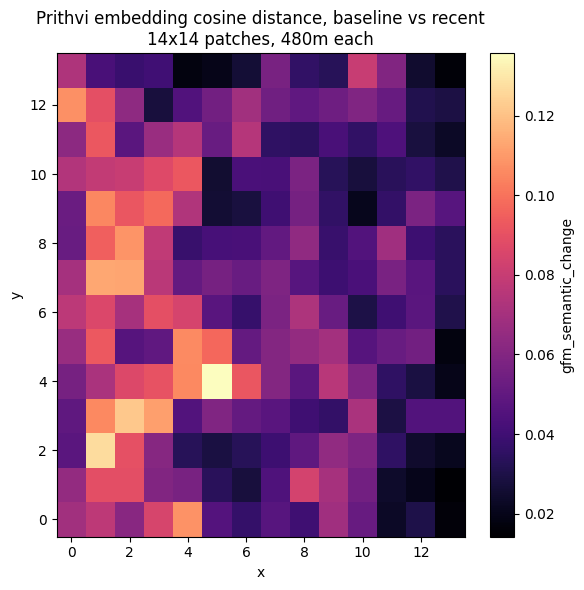

mean cosine distance: 0.055796585977077484
max cosine distance: 0.1357390284538269


In [37]:
def cosine_distance_grid(embed_a, embed_b):
    a = embed_a.reshape(-1, embed_a.shape[-1])
    b = embed_b.reshape(-1, embed_b.shape[-1])
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    cos_sim = (a_norm * b_norm).sum(axis=1)
    cos_dist = 1 - cos_sim
    return cos_dist.reshape(embed_a.shape[0], embed_a.shape[1])

gfm_change = cosine_distance_grid(baseline_embed, recent_embed)

grid_size = gfm_change.shape[0]
patch_pixels = 224 // grid_size
token_transform = crop_transform * Affine.scale(patch_pixels)

gfm_da = xr.DataArray(gfm_change, dims=["y", "x"], name="gfm_semantic_change")
gfm_da = gfm_da.rio.write_transform(token_transform)
gfm_da = gfm_da.rio.write_crs(baseline_bands_median.rio.crs)

fig, ax = plt.subplots(figsize=(6, 6))
gfm_da.plot(ax=ax, cmap="magma")
ax.set_title("Prithvi embedding cosine distance, baseline vs recent\n14x14 patches, 480m each")
plt.tight_layout()
plt.savefig("gfm_semantic_change.png", dpi=150)
plt.show()

print("mean cosine distance:", float(gfm_change.mean()))
print("max cosine distance:", float(gfm_change.max()))

### Checking this against what the rest of the pipeline already found

So far the Prithvi output has just been an image to look at, on its own it doesn't say anything about whether it agrees or disagrees with the NDVI and BSI based results. Turning each of the 196 grid cells into an actual polygon, using the affine transform directly rather than a built in helper, makes it possible to ask that question properly, a spatial join against the 129 already ranked polygons, checking which of them physically overlap the small area Prithvi covers.

The count printed here counts join rows, not distinct polygons, a large polygon spanning several Prithvi cells shows up once per cell it touches, so this number will come out higher than the real count of polygons involved. That gets fixed in the next step, this is just the raw overlap before cleaning it up.

In [38]:
gfm_polygons = []
gfm_values = []
for i in range(grid_size):
    for j in range(grid_size):
        cell_minx = token_transform.c + j * token_transform.a
        cell_maxx = cell_minx + token_transform.a
        cell_maxy = token_transform.f + i * token_transform.e
        cell_miny = cell_maxy + token_transform.e
        gfm_polygons.append(box(cell_minx, cell_miny, cell_maxx, cell_maxy))
        gfm_values.append(gfm_change[i, j])

gfm_gdf = gpd.GeoDataFrame({"cosine_distance": gfm_values}, geometry=gfm_polygons, crs=baseline_bands_median.rio.crs).to_crs(4326)

overlap_gfm = gpd.sjoin(ranked, gfm_gdf, how="inner", predicate="intersects")
print(f"{len(overlap_gfm)} of the {len(ranked)} flagged polygons fall inside the Prithvi crop area")
if len(overlap_gfm) > 0:
    print(overlap_gfm[["priority_rank", "severity", "area_ha", "cosine_distance"]].sort_values("cosine_distance", ascending=False))

156 of the 129 flagged polygons fall inside the Prithvi crop area
     priority_rank severity  area_ha  cosine_distance
9               10     high    20.47         0.135739
12              13   medium    14.90         0.135739
0                1     high   176.99         0.126973
0                1     high   176.99         0.121673
1                2   medium   163.47         0.113046
..             ...      ...      ...              ...
59              60   medium     2.00         0.037979
123            124      low     0.53         0.037334
79              80   medium     1.26         0.037334
67              68   medium     1.62         0.028550
93              94      low     0.94         0.024846

[156 rows x 4 columns]


### Collapsing duplicate rows back into one per polygon

Grouping by priority_rank fixes the inflated count from the join, polygons that touched multiple Prithvi cells get folded back into a single row. Severity and area don't change across those duplicate rows, they belong to the polygon itself, so taking the first value is fine there. Cosine distance is different, each duplicate row came from a different Prithvi cell with its own value, so those get genuinely aggregated, the mean for an overall sense of how changed the surrounding area looks, the max for the single most extreme cell that polygon happens to touch.

This is also what keeps the next step honest, without collapsing duplicates first, any correlation calculated afterward would be quietly skewed toward large polygons just for showing up more times, not for being more significant.

In [39]:
n_unique_polygons = overlap_gfm["priority_rank"].nunique()
print(f"{n_unique_polygons} distinct flagged polygons (out of {len(ranked)}) fall inside the Prithvi crop area")

overlap_summary = overlap_gfm.groupby("priority_rank").agg(
    severity=("severity", "first"),
    area_ha=("area_ha", "first"),
    mean_cosine_distance=("cosine_distance", "mean"),
    max_cosine_distance=("cosine_distance", "max"),
).sort_values("mean_cosine_distance", ascending=False)

print(overlap_summary)

51 distinct flagged polygons (out of 129) fall inside the Prithvi crop area
              severity  area_ha  mean_cosine_distance  max_cosine_distance
priority_rank                                                             
10                high    20.47              0.111124             0.135739
119                low     0.60              0.107345             0.107345
98                 low     0.82              0.101527             0.105974
122                low     0.57              0.098625             0.105300
125                low     0.51              0.096475             0.108138
106                low     0.72              0.094845             0.097739
13              medium    14.90              0.093738             0.135739
79              medium     1.28              0.092263             0.092263
67              medium     1.63              0.091951             0.091951
105                low     0.74              0.089535             0.089535
9               medium  

### What this table actually shows

Read this table by checking whether severity and Prithvi distance line up. If small, low severity polygons and large, high severity ones both turn up scattered across the full range of cosine distance rather than sorting cleanly by severity, high-distance entries all high severity, low-distance entries all low severity, that's evidence the two signals are responding to different things rather than one just restating the other.

The gap between a polygon's mean and max distance is also worth checking directly. A polygon spanning several Prithvi cells can show a much higher max than mean if only one of its cells carries a strong semantic shift, while a polygon small enough to touch only a single cell will always show mean equal to max, there's nothing to average over. Large polygons hiding internal variation behind one averaged number is the same resolution mismatch already flagged earlier, a single 480m grid cell can't describe a multi-hectare polygon with much precision either way, regardless of which specific polygons happen to land where in a given run.

### Putting a real number on the relationship instead of eyeballing the table

Spearman correlation works on ranks rather than raw values, catching a monotonic relationship even if it isn't perfectly linear, and it's less thrown off by a couple of extreme outliers than a straightforward correlation on the raw numbers would be. Area and mean cosine distance go in as the two variables, the same 51 polygons from the table above, one point each.

The scatter plot backs up whatever the correlation coefficient turns out to be, color coded by severity so it's obvious at a glance whether red, orange, and gray points cluster into separate bands or mix together across the full range. If they mix, that's the same story the raw table was already telling, just with an actual statistic behind it instead of an impression from scanning a column of numbers.

Spearman correlation, area vs GFM distance: 0.053 (p=0.709)


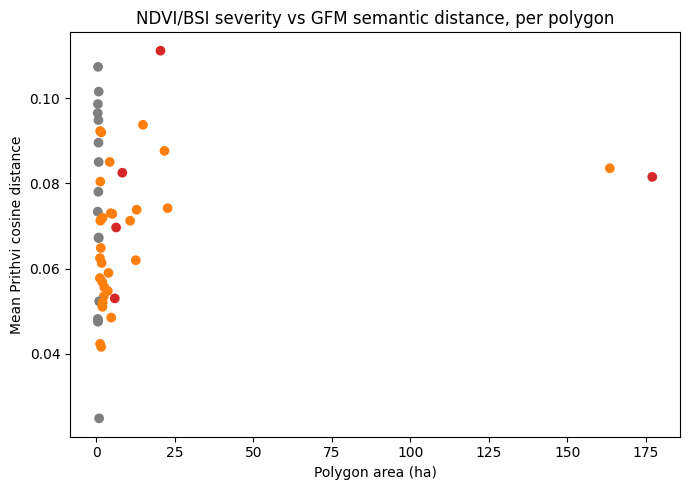

In [40]:
correlation, p_value = spearmanr(overlap_summary["area_ha"], overlap_summary["mean_cosine_distance"])
print(f"Spearman correlation, area vs GFM distance: {correlation:.3f} (p={p_value:.3f})")

fig, ax = plt.subplots(figsize=(7, 5))
colors = overlap_summary["severity"].map({"high": "tab:red", "medium": "tab:orange", "low": "tab:gray"})
ax.scatter(overlap_summary["area_ha"], overlap_summary["mean_cosine_distance"], c=colors)
ax.set_xlabel("Polygon area (ha)")
ax.set_ylabel("Mean Prithvi cosine distance")
ax.set_title("NDVI/BSI severity vs GFM semantic distance, per polygon")
plt.tight_layout()
plt.savefig("gfm_vs_severity.png", dpi=150)
plt.show()

### What this comparison actually means

The correlation coefficient and p-value printed above are the first thing to check, anything far from conventional significance means there's no real evidence of a relationship between how large a polygon is and how much Prithvi thinks that spot changed. The scatter plot is the visual version of the same check, if red, orange, and gray points mix together across the full vertical range rather than separating into bands, that tells the same story as a weak correlation. It's worth specifically checking where the two largest polygons in the whole dataset, roughly 177 and 163 hectares, land on that plot, since a foundation model that mainly just responds to how big a patch is on the ground wouldn't be adding anything band math doesn't already give for free.

A weak or absent correlation here wouldn't be strong evidence that the foundation model has nothing useful to say, 51 points confined to one corner of the AOI is a small, biased sample to draw a firm conclusion from either way. What it would show is that Prithvi embedding distance and the NDVI plus BSI severity score are picking up on something different from each other. If they lined up neatly, that would actually be the less interesting outcome, just the same signal restated in a more expensive way. Disagreement here would be more informative than agreement, even if there isn't enough data yet to say exactly what the model is responding to that the band math misses.

### Where GFM sees something band-math doesn't

The correlation check above answers whether GFM distance and severity broadly track each other, and the answer was no, not strongly. That's useful but still abstract, it doesn't say which specific polygons are the interesting disagreements. The actual point of running a foundation model here, using the brief's own wording, is to surface information band-math indices couldn't give, not just to confirm or contradict them in aggregate.

So this asks a narrower question directly: which polygons did the NDVI/BSI rule rank as low priority that Prithvi's embedding distance treats as strongly changed anyway. Low severity here mostly means small area, under a hectare in every case in this table, exactly the size where a rule built on a fixed area threshold is least confident and most likely to either over- or under-flag something. A polygon in that bucket with an unusually high semantic distance is a candidate the band-math rule alone would have buried near the bottom of a 129 row list, worth a second look rather than treated as noise.

The threshold used here, the 75th percentile of mean_cosine_distance across all 51 polygons touched by the Prithvi crop, is a relative cut calibrated against this specific AOI and run, not a fixed constant, worth stating as a limit up front rather than after the fact.

In [41]:
gfm_q75 = overlap_summary["mean_cosine_distance"].quantile(0.75)

gfm_disagreements = overlap_summary[
    (overlap_summary["severity"] == "low") &
    (overlap_summary["mean_cosine_distance"] > gfm_q75)
].sort_values("mean_cosine_distance", ascending=False)

print(f"75th percentile of GFM mean cosine distance across the {len(overlap_summary)} polygons: {gfm_q75:.3f}")
print(f"{len(gfm_disagreements)} low-severity polygons sit above that, despite being ranked low priority by NDVI/BSI alone:")
print(gfm_disagreements)

75th percentile of GFM mean cosine distance across the 51 polygons: 0.084
7 low-severity polygons sit above that, despite being ranked low priority by NDVI/BSI alone:
              severity  area_ha  mean_cosine_distance  max_cosine_distance
priority_rank                                                             
119                low     0.60              0.107345             0.107345
98                 low     0.82              0.101527             0.105974
122                low     0.57              0.098625             0.105300
125                low     0.51              0.096475             0.108138
106                low     0.72              0.094845             0.097739
105                low     0.74              0.089535             0.089535
99                 low     0.80              0.085013             0.107345


### What this list is for

These seven polygons, priority ranks 119, 98, 122, 125, 106, 105 and 99, are all under a hectare and would sit near the bottom of the enforcement ranked list if area and NDVI/BSI severity were the only sort key. Prithvi's embedding distance disagrees, ranking each of them among the top third of all 51 polygons it actually looked at, comparable to or higher than several medium and high severity polygons several times their size.

This does not mean these seven are confirmed deforestation. At 480 meters per GFM cell and under a hectare per polygon, the resolution mismatch already flagged earlier applies directly here, one Prithvi cell can easily be dominated by whatever else sits inside its footprint beyond the flagged polygon itself. What it does mean is that these are the seven places in the whole AOI where the two independent detection approaches disagree the most, small and easy to overlook by area alone, but flagged as meaningfully changed by a model trained on a much broader visual vocabulary than four spectral ratios. That is a concrete, second list an enforcement team could add to the primary ranked table, not a replacement for it, and it is exactly the kind of information the band-math indices alone were not going to surface.

### One more limit on the two-period comparison

Comparing a single dry season window in 2018 against one in 2023 only tells you the net difference between those two snapshots, it says nothing about what happened in between. An area cleared in 2019 and already regrown into pasture grass or secondary vegetation by 2023 could easily show little or no NDVI drop here, and the reverse is also possible, a spot degraded gradually across several years might only cross the -0.25 threshold right at the end of the window, with the pipeline never seeing the intermediate stages at all. A proper monitoring setup for this AOI would need more than two snapshots, ideally an annual or seasonal series across the whole gap, not just a before and after.